 The Death of the Entry-Level Developer
 Data Analysis 



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('surveydata.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (23, 8)


,respondent_id,q1_ai_job_harder,q2_worry_scale,q3_changed_electives,q4_ai_project_grade,q5_stop_teaching_syntax,q6_bar_raised,q7_ai_code_share
0,1,A little harder,4,Yes I've changed my focus,Yes they used their tools effectively,No you still need the basics,Yes the bar is much higher now,26-50% (most of the logic)
1,2,A little harder,3,I'm thinking about it,Only if they can explain every line manually,Yes the old way is becoming obsolete,Yes the bar is much higher now,1-25% (small fixes)
2,3,Yes much harder,5,I'm thinking about it,Yes they used their tools effectively,Yes the old way is becoming obsolete,Yes the bar is much higher now,Over 50% (AI builds the bulk)
3,4,A little harder,4,Yes I've changed my focus,Only if they can explain every line manually,No you still need the basics,Yes the bar is much higher now,1-25% (small fixes)
4,5,A little harder,3,Yes I've changed my focus,Yes they used their tools effectively,No you still need the basics,Yes the bar is much higher now,26-50% (most of the logic)


## 1. Data Overview

In [2]:
print('Column names:', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())
print(f'\nTotal respondents: {len(df)}')

Column names: ['respondent_id', 'q1_ai_job_harder', 'q2_worry_scale', 'q3_changed_electives', 'q4_ai_project_grade', 'q5_stop_teaching_syntax', 'q6_bar_raised', 'q7_ai_code_share']

Missing values:
respondent_id              0
q1_ai_job_harder           0
q2_worry_scale             0
q3_changed_electives       0
q4_ai_project_grade        0
q5_stop_teaching_syntax    0
q6_bar_raised              0
q7_ai_code_share           0
dtype: int64

Total respondents: 23


## 2. Descriptive Statistics — Q2 Worry Scale (Numerical)

In [3]:
worry = df['q2_worry_scale']

print(f'Mean:{worry.mean():.2f}')
print(f'Median: {worry.median():.1f}')
print(f'Mode:{worry.mode()[0]}')
print(f'Std Dev:{worry.std():.2f}')
print(f'Min:{worry.min()} Max: {worry.max()}')
print(f'\nValue counts:')
print(worry.value_counts().sort_index())

Mean:3.26
Median: 3.0
Mode:4
Std Dev:1.29
Min:1 Max: 5

Value counts:
q2_worry_scale
1    3
2    3
3    6
4    7
5    4
Name: count, dtype: int64


## 3. Q1 — Will AI Make It Harder to Get a Junior Dev Job?

Q1 Response counts:
q1_ai_job_harder
A little harder                    13
Yes much harder                     6
It will actually make it easier     4
Name: count, dtype: int64

Percentages:
q1_ai_job_harder
A little harder                    56.5
Yes much harder                    26.1
It will actually make it easier    17.4
Name: count, dtype: float64


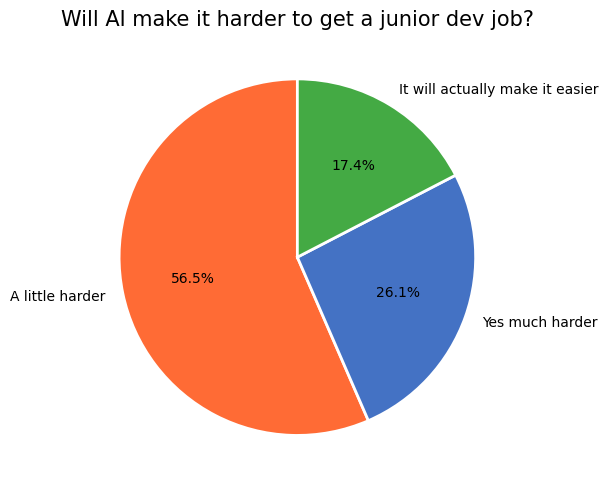

In [4]:
q1 = df['q1_ai_job_harder'].value_counts()
print('Q1 Response counts:')
print(q1)
print('\nPercentages:')
print((q1 / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#FF6B35', '#4472C4', '#44AA44', '#FFC107']
q1.plot(kind='pie', ax=ax, colors=colors[:len(q1)], autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Will AI make it harder to get a junior dev job?', fontsize=15)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 4. Q2 — Worry Scale Bar Chart

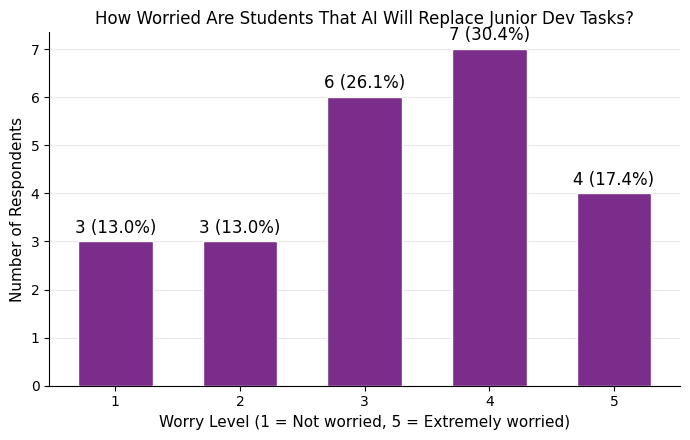

In [5]:
q2_counts = df['q2_worry_scale'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(q2_counts.index, q2_counts.values, color='#7B2D8B', edgecolor='white', width=0.6)

for bar in bars:
    pct = bar.get_height() / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{int(bar.get_height())} ({pct:.1f}%)', ha='center', va='bottom', fontsize=12)

ax.set_xlabel('Worry Level (1 = Not worried, 5 = Extremely worried)', fontsize=11)
ax.set_ylabel('Number of Respondents', fontsize=11)
ax.set_title('How Worried Are Students That AI Will Replace Junior Dev Tasks?', fontsize=12)
ax.set_xticks([1,2,3,4,5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 5. Q3 — Changing Electives Due to Automation Fear

Q3 counts:
q3_changed_electives
I'm thinking about it                  12
Yes I've changed my focus               8
No I'm sticking to my original plan     3
Name: count, dtype: int64


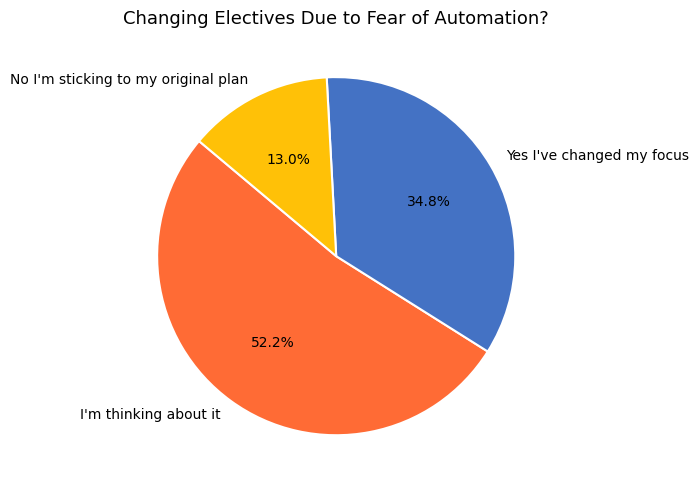

In [6]:
q3 = df['q3_changed_electives'].value_counts()
print('Q3 counts:')
print(q3)

fig, ax = plt.subplots(figsize=(7, 5))
colors3 = ['#FF6B35', '#4472C4', '#FFC107']
q3.plot(kind='pie', ax=ax, colors=colors3[:len(q3)], autopct='%1.1f%%',
        startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Changing Electives Due to Fear of Automation?', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Q4 — If AI Writes 80% of the Project, Should the Student Still Get an "A"?

Q4 counts:
q4_ai_project_grade
Yes they used their tools effectively           10
Only if they can explain every line manually    10
No that's cheating/lazy                          3
Name: count, dtype: int64

Percentages:
q4_ai_project_grade
Yes they used their tools effectively           43.5
Only if they can explain every line manually    43.5
No that's cheating/lazy                         13.0
Name: count, dtype: float64


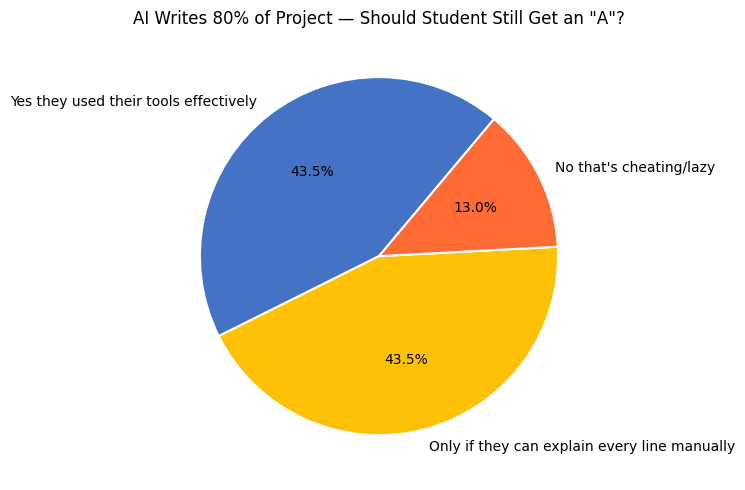

In [7]:
q4 = df['q4_ai_project_grade'].value_counts()
print('Q4 counts:')
print(q4)
print('\nPercentages:')
print((q4 / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 5))
colors4 = ['#4472C4', '#FFC107', '#FF6B35']
q4.plot(kind='pie', ax=ax, colors=colors4[:len(q4)], autopct='%1.1f%%',
        startangle=50, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('AI Writes 80% of Project — Should Student Still Get an "A"?', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 7. Q5 — Should Universities Stop Teaching Basic Syntax?

Q5 counts:
q5_stop_teaching_syntax
No you still need the basics            17
Yes the old way is becoming obsolete     6
Name: count, dtype: int64

Percentages:
q5_stop_teaching_syntax
No you still need the basics            73.9
Yes the old way is becoming obsolete    26.1
Name: count, dtype: float64


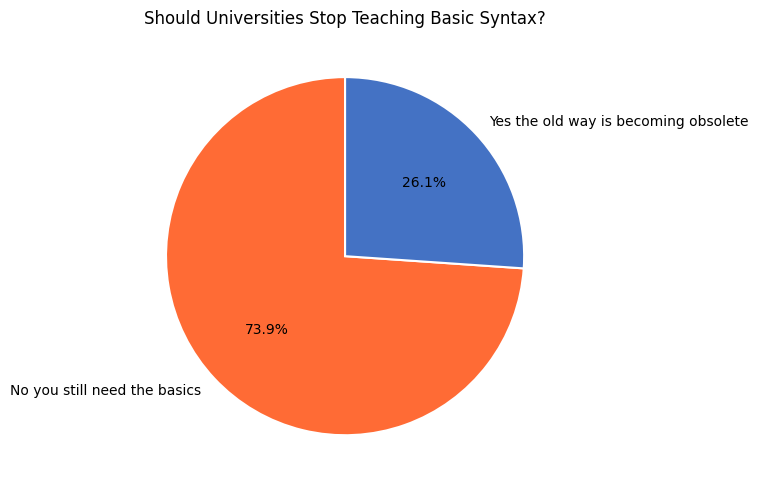

In [8]:
q5 = df['q5_stop_teaching_syntax'].value_counts()
print('Q5 counts:')
print(q5)
print('\nPercentages:')
print((q5 / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 5))
colors5 = ['#FF6B35', '#4472C4']
q5.plot(kind='pie', ax=ax, colors=colors5[:len(q5)], autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Should Universities Stop Teaching Basic Syntax?', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 8. Q6 — Is the Bar for Junior Devs Higher Today?

Q6 counts:
q6_bar_raised
Yes the bar is much higher now    21
No expectations are the same       1
Unsure                             1
Name: count, dtype: int64

Percentages:
q6_bar_raised
Yes the bar is much higher now    91.3
No expectations are the same       4.3
Unsure                             4.3
Name: count, dtype: float64


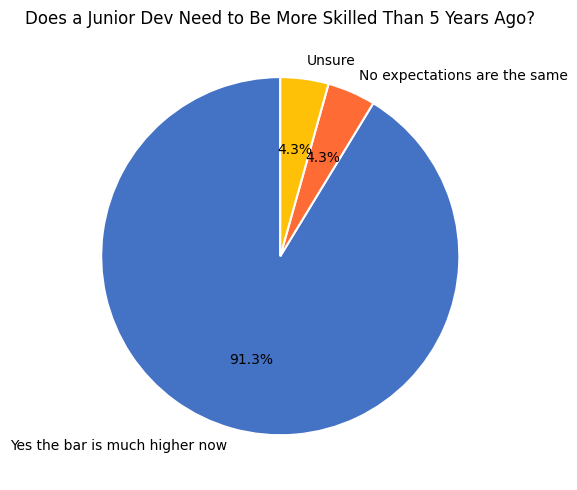

In [9]:
q6 = df['q6_bar_raised'].value_counts()
print('Q6 counts:')
print(q6)
print('\nPercentages:')
print((q6 / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 5))
colors6 = ['#4472C4', '#FF6B35', '#FFC107']
q6.plot(kind='pie', ax=ax, colors=colors6[:len(q6)], autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Does a Junior Dev Need to Be More Skilled Than 5 Years Ago?', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 9. Q7 — How Much Code Is Written by AI?

Q7 counts:
q7_ai_code_share
26-50% (most of the logic)       9
1-25% (small fixes)              9
Over 50% (AI builds the bulk)    5
Name: count, dtype: int64


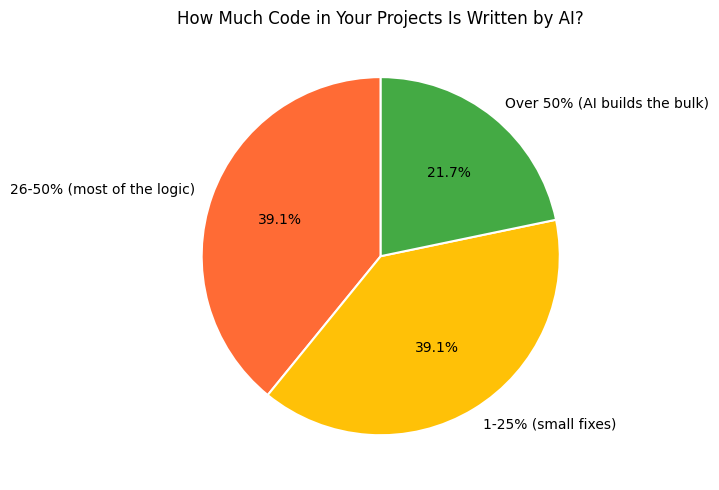

In [10]:
q7 = df['q7_ai_code_share'].value_counts()
print('Q7 counts:')
print(q7)

fig, ax = plt.subplots(figsize=(7, 5))
colors7 = ['#FF6B35', '#FFC107', '#44AA44']
q7.plot(kind='pie', ax=ax, colors=colors7[:len(q7)], autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('How Much Code in Your Projects Is Written by AI?', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 10. Full Summary — All Questions

In [12]:
print(f'\nTotal Respondents: {len(df)}')
print(f'\nQ2 Worry Scale (1-5):')
print(f'  Mean: {df["q2_worry_scale"].mean():.2f}')
print(f'  Median: {df["q2_worry_scale"].median()}')
print(f'  Mode: {df["q2_worry_scale"].mode()[0]}')

print(f'\nQ1 — AI makes job harder:')
harder = df['q1_ai_job_harder'].isin(['A little harder','Yes much harder']).sum()
print(f'  {harder}/{len(df)} = {harder/len(df)*100:.1f}% believe AI makes it harder')

print(f'\nQ3 — Changed or considering changing electives:')
changed = df['q3_changed_electives'].isin(["Yes I've changed my focus","I'm thinking about it"]).sum()
print(f'  {changed}/{len(df)} = {changed/len(df)*100:.1f}% changed or considering')

print(f'\nQ6 — Bar is higher for junior devs:')
bar_higher = (df['q6_bar_raised'] == 'Yes the bar is much higher now').sum()
print(f'  {bar_higher}/{len(df)} = {bar_higher/len(df)*100:.1f}% agree bar is higher')

print(f'\nQ7 — AI writes >25% of code:')
ai_heavy = df['q7_ai_code_share'].isin(['26-50% (most of the logic)','Over 50% (AI builds the bulk)']).sum()
print(f'  {ai_heavy}/{len(df)} = {ai_heavy/len(df)*100:.1f}% rely on AI for >25% of code')


Total Respondents: 23

Q2 Worry Scale (1-5):
  Mean: 3.26
  Median: 3.0
  Mode: 4

Q1 — AI makes job harder:
  19/23 = 82.6% believe AI makes it harder

Q3 — Changed or considering changing electives:
  20/23 = 87.0% changed or considering

Q6 — Bar is higher for junior devs:
  21/23 = 91.3% agree bar is higher

Q7 — AI writes >25% of code:
  14/23 = 60.9% rely on AI for >25% of code
